In [1]:
library(plyr)
library(dplyr)
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(devtools)
library(here)
library(rlucas)
library(reticulate)
library(cowplot)
library(FSelectorRcpp)

dir.create("../../outputs/Extended/Supple-Fig-2-protein_boxplots/", recursive = TRUE, showWarnings = FALSE)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:plyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::arrange()   masks plyr::arrange()
✖ purrr::compact()   masks plyr::compact()
✖ dplyr::count()     masks plyr::count()
✖ dplyr::desc()      masks plyr::desc()
✖ dplyr::failwith()  masks plyr::failwith()
✖ dplyr::fil

In [2]:
lucas_df <- read.csv("../../data/lucas_df_with_pcs.csv")

lucas_df <- lucas_df %>%
  mutate(clinical_CEA = log2(clinical_CEA + 1))
lucas_df <- lucas_df %>% select(-olink_CEA)
merged_df <- lucas_df

In [3]:
library(tidyverse)
library(ggsignif)

plot_biomarker_stage <- function(df, biomarker_col, biomarker_name, origin) {
  # Prepare data and stage grouping
  df <- df %>%
    mutate(
      StageGroup = case_when(
        is.na(Stage) ~ "Non-cancer",
        Stage %in% c("I", "II") ~ "I/II",
        Stage == "III" ~ "III",
        Stage == "IV" ~ "IV",
        TRUE ~ NA_character_
      ),
      StageGroup = factor(StageGroup, levels = c("Non-cancer", "I/II", "III", "IV"))
    ) %>%
    filter(!is.na(.data[[biomarker_col]]))
  
  # Define colors for groups based on origin
  if (origin == "Tumor Intrinsic") {
    fill_colors <- c(
      "Non-cancer" = "grey50",
      "I/II" = "#FFCCCB", 
      "III" = "#FFA07A", 
      "IV" = "#CD5C5C"
    )
  } else {
    fill_colors <- c(
      "Non-cancer" = "grey50",
      "I/II" = "#9ECAE1",
      "III" = "#4292C6",
      "IV" = "#08519C"
    )
  }

  # Define pairwise comparisons vs Non-cancer
  comparisons <- list(
    c("Non-cancer", "I/II"),
    c("Non-cancer", "III"),
    c("Non-cancer", "IV")
  )
  
  # y min fixed at zero, y max from data
  y_max <- max(df[[biomarker_col]], na.rm = TRUE)
  
  # Significance lines above boxplots
  y_positions <- y_max * c(1.1, 1.2, 1.3)
  
  # Plot
  p <- ggplot(df, aes(x = StageGroup, y = .data[[biomarker_col]], fill = StageGroup)) +
    geom_boxplot(alpha = 0.7, outlier.shape = NA, width = 0.3) +
    geom_jitter(width = 0.15, size = 1, alpha = 0.6) +
    scale_fill_manual(values = fill_colors) +
    labs(
      title = paste(""),
      x = NULL,
      y = paste0("", biomarker_name, " (NPX)")
    ) +
    scale_y_continuous(
      expand = expansion(mult = c(0, 0.1)),
      limits = c(0, NA),
      breaks = scales::pretty_breaks(n = 6)
    ) +
    theme_classic(base_size = 14) +
    theme(
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      axis.title.y = element_text(size = 30),
      axis.text.x = element_text(size = 25, color = "black", margin = margin(t = 10)),
      axis.text.y = element_text(size = 20),
      panel.grid.major.y = element_line(color = "grey90", size = 0.3),
      legend.position = "none"
    ) +
    geom_signif(
      comparisons = comparisons,
      y_position = y_positions,
      map_signif_level = TRUE,
      test = "t.test",
      size = 1.5,
      textsize = 8,
      tip_length = 0.01
    )
  
  # Sample size labels just above zero
  sample_sizes <- df %>%
    group_by(StageGroup) %>%
    summarise(n = n(), .groups = "drop") %>%
    arrange(factor(StageGroup, levels = levels(df$StageGroup)))
  
  label_ypos <- 0.5  # If you want even closer to zero, can try 0.2 or similar
  for (i in seq_len(nrow(sample_sizes))) {
    p <- p + annotate("text",
                      x = i,
                      y = label_ypos,
                      label = paste0("n = ", sample_sizes$n[i]),
                      size = 6,
                      color = "black")
  }
  
  print(p)
}

options(repr.plot.width = 9, repr.plot.height = 12, repr.plot.res = 500)



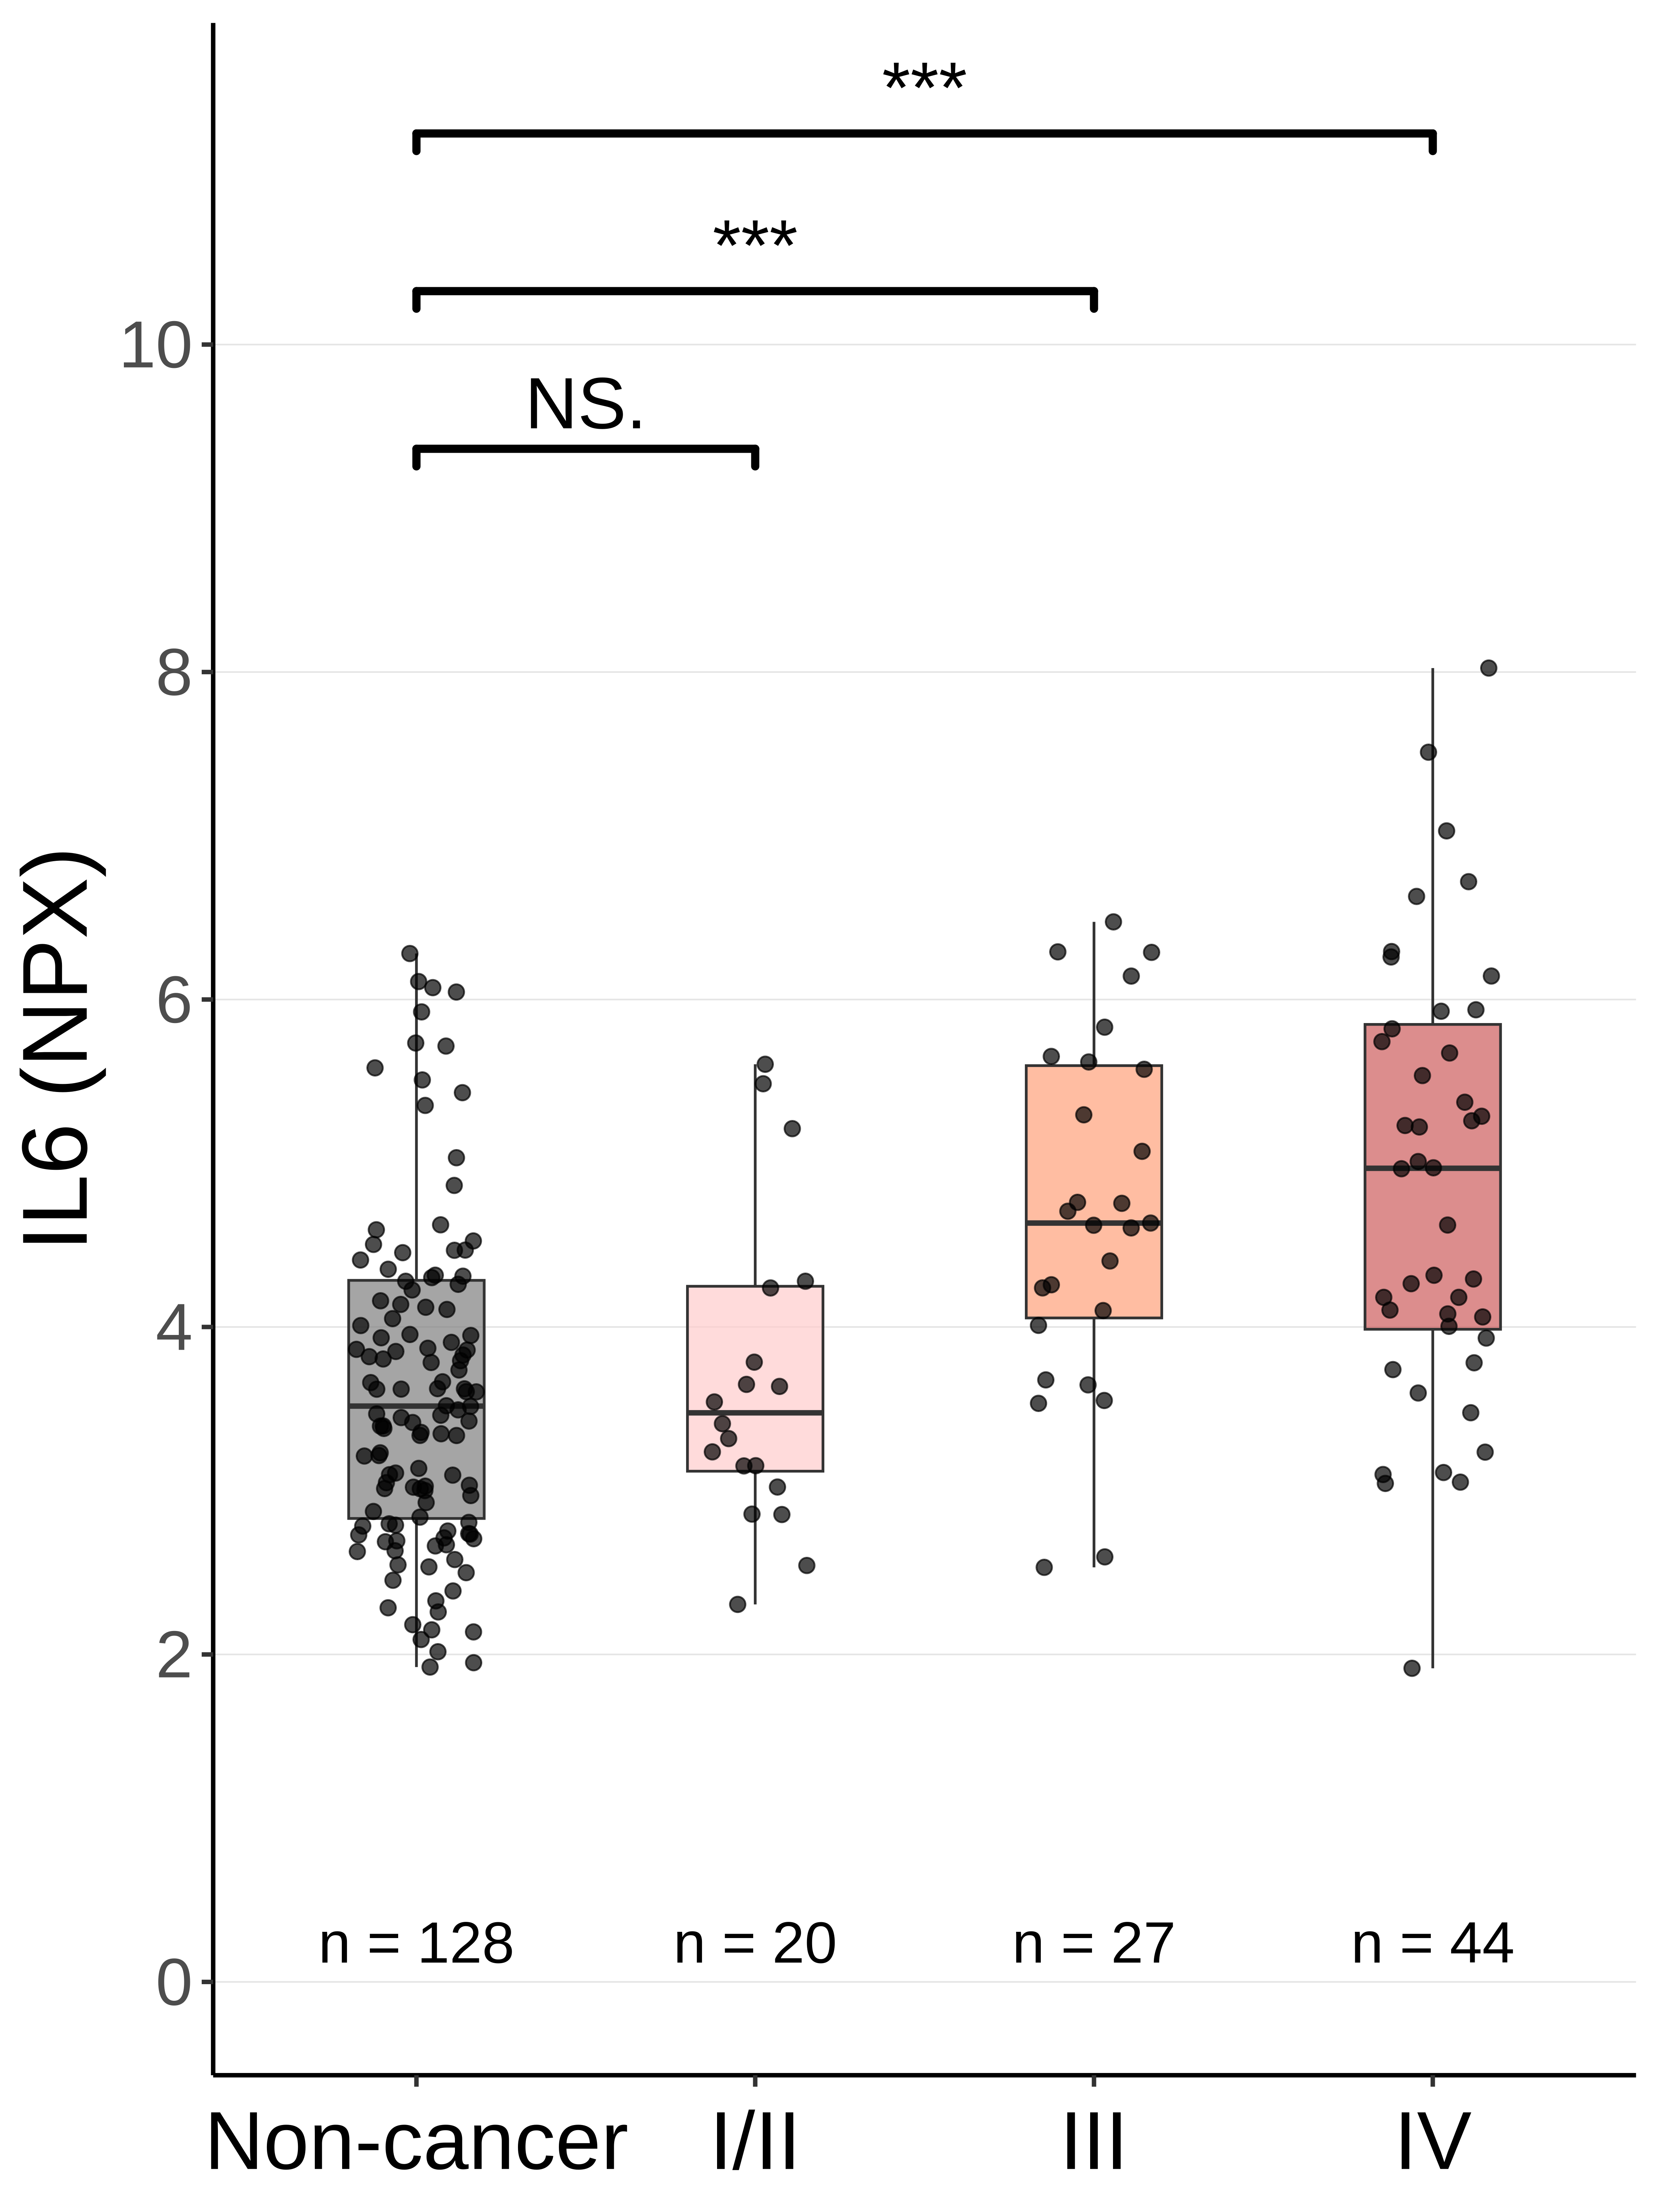

In [4]:
library(tidyverse)
library(ggsignif)

plot_biomarker_stage <- function(df, biomarker_col, biomarker_name, origin) {
  df <- df %>%
    mutate(
      StageGroup = case_when(
        is.na(Stage) ~ "Non-cancer",
        Stage %in% c("I", "II") ~ "I/II",
        Stage == "III" ~ "III",
        Stage == "IV" ~ "IV",
        TRUE ~ NA_character_
      ),
      StageGroup = factor(StageGroup, levels = c("Non-cancer", "I/II", "III", "IV"))
    ) %>%
    filter(!is.na(.data[[biomarker_col]]))
  
  if (origin == "Tumor Intrinsic") {
    fill_colors <- c(
      "Non-cancer" = "grey50",
      "I/II" = "#FFCCCB", 
      "III" = "#FFA07A", 
      "IV" = "#CD5C5C"
    )
  } else {
    fill_colors <- c(
      "Non-cancer" = "grey50",
      "I/II" = "#9ECAE1",
      "III" = "#4292C6",
      "IV" = "#08519C"
    )
  }

  comparisons <- list(
    c("Non-cancer", "I/II"),
    c("Non-cancer", "III"),
    c("Non-cancer", "IV")
  )
  
  # --- Identify outliers per group (1.5x IQR rule, same as boxplot uses) ---
  outlier_bounds <- df %>%
    group_by(StageGroup) %>%
    summarise(
      lower = quantile(.data[[biomarker_col]], 0.25) - 1.5 * IQR(.data[[biomarker_col]]),
      upper = quantile(.data[[biomarker_col]], 0.75) + 1.5 * IQR(.data[[biomarker_col]]),
      .groups = "drop"
    )
  
  # Non-outlier points only — used for jitter layer
  df_no_outliers <- df %>%
    left_join(outlier_bounds, by = "StageGroup") %>%
    filter(.data[[biomarker_col]] >= lower & .data[[biomarker_col]] <= upper)

  # Zoom ceiling based on the non-outlier data
  zoom_max <- max(df_no_outliers[[biomarker_col]], na.rm = TRUE)
  y_positions <- zoom_max * c(1.10, 1.22, 1.34)
  
  p <- ggplot(df, aes(x = StageGroup, y = .data[[biomarker_col]], fill = StageGroup)) +
    geom_boxplot(alpha = 0.7, outlier.shape = NA, width = 0.4) +  # outlier.shape = NA hides default outlier dots
    geom_jitter(
      data = df_no_outliers,   # ← only non-outlier points plotted
      width = 0.18, size = 2.5, alpha = 0.7
    ) +
    scale_fill_manual(values = fill_colors) +
    labs(x = NULL, y = paste0(biomarker_name, " (NPX)")) +
    scale_y_continuous(breaks = scales::pretty_breaks(n = 6)) +
    coord_cartesian(ylim = c(0, zoom_max * 1.42)) +
    theme_classic(base_size = 18) +
    theme(
      plot.title         = element_text(hjust = 0.5, size = 20, face = "bold"),
      axis.title.y       = element_text(size = 36),
      axis.text.x        = element_text(size = 32, color = "black", margin = margin(t = 10)),
      axis.text.y        = element_text(size = 26),
      panel.grid.major.y = element_line(color = "grey90", linewidth = 0.3),
      legend.position    = "none"
    ) +
    geom_signif(
      comparisons      = comparisons,
      y_position       = y_positions,
      map_signif_level = TRUE,
      test             = "t.test",
      size             = 1.5,
      textsize         = 10,
      tip_length       = 0.01
    )
  
  # Sample sizes from full data (not filtered)
  sample_sizes <- df %>%
    group_by(StageGroup) %>%
    summarise(n = n(), .groups = "drop") %>%
    arrange(factor(StageGroup, levels = levels(df$StageGroup)))
  
  label_ypos <- zoom_max * 0.03
  for (i in seq_len(nrow(sample_sizes))) {
    p <- p + annotate("text",
                      x     = i,
                      y     = label_ypos,
                      label = paste0("n = ", sample_sizes$n[i]),
                      size  = 8,
                      color = "black")
  }
  
  print(p)
}

options(repr.plot.width = 9, repr.plot.height = 12, repr.plot.res = 500)
plot_biomarker_stage(lucas_df, biomarker_col = "olink_IL6", biomarker_name = "IL6", origin = "Tumor Intrinsic")

In [5]:
save_all_plots <- function(merged_df, output_dir, biomarker_list, origin = "Tumor Intrinsic") {
  dir.create(output_dir, showWarnings = FALSE)
  
  for (biomarker_col in biomarker_list) {
    # Extract biomarker name from column (remove "olink_" prefix if present)
    biomarker_name <- gsub("^olink_", "", biomarker_col)
    
    safe_name <- gsub("[^a-zA-Z0-9_\\-]", "_", biomarker_name)
    plot_file <- file.path(output_dir, paste0(safe_name, ".png"))
    
    png(filename = plot_file, width = 9, height = 10, units = "in", res = 500)
    plot_biomarker_stage(merged_df, biomarker_col, biomarker_name, origin)
    dev.off()
  }
}

# Usage
my_biomarkers <- c("olink_FASLG", "olink_IL12", "olink_ICOSLG", "olink_PDCD1", 
                  "olink_CD28", "olink_CRTAM", "olink_GZMA", "olink_GZMH", "olink_CD244", "olink_IL12RB1")

save_all_plots(merged_df, "../../outputs/Extended/Supple-Fig-2-protein_boxplots/", biomarker_list = my_biomarkers, origin = "Tumor Extrinsic")


In [ ]:
# Done #